In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset,SubsetRandomSampler
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
import numpy as np
from tqdm import tqdm

In [3]:
# load spectrogram images
data_dir_td = '/content/drive/MyDrive/ff/spectrogram/' # spectrogram

# preprocess the images
transform_td = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_td = datasets.ImageFolder(root=data_dir_td, transform=transform_td)

# Extract indices and labels
indices = list(range(len(dataset_td)))
labels = [label for _, label in dataset_td.samples]

# Split indices into train and test
train_indices, test_indices = train_test_split(
    indices,
    test_size=0.2,  # Adjust the test size as needed
    stratify=labels,  # Perform stratified sampling
    random_state=42  # For reproducibility
)

# Create Subset datasets
train_dataset_td = Subset(dataset_td, train_indices)
test_dataset_td = Subset(dataset_td, test_indices)

1303
326
('/content/drive/MyDrive/ff/spectrogram/3/3P02A03R01.dat_spec.jpg', 2)


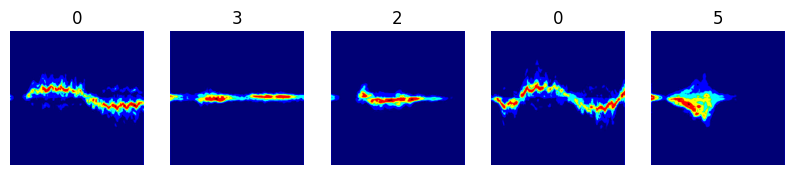

In [4]:
print(len(train_dataset_td))
print(len(test_dataset_td))
print(dataset_td.imgs[577])

def show_image(img, title=""):
    # Convert the tensor to a numpy array and transpose to (H, W, C)
    img = np.transpose(img.numpy(), (1, 2, 0))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

# Visualize a few images
plt.figure(figsize=(10, 5))
for i in range(5):
  img, img_name = train_dataset_td[i]
  plt.subplot(1, 5, i + 1)
  show_image(img, title=img_name)
plt.show()

In [5]:
def is_image_file(filename):
    valid_image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif')
    return filename.lower().endswith(valid_image_extensions)

# load masked spectrogram images
data_dir_mask = '/content/drive/MyDrive/ff/masked_spectrogram/'

# preprocess the images
transform_mask = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_mask = datasets.ImageFolder(root=data_dir_mask, transform=transform_mask, is_valid_file=is_image_file)

# Extract indices and labels
indices = list(range(len(dataset_mask)))
labels = [label for _, label in dataset_mask.samples]

# Split indices into train and test
train_indices, test_indices = train_test_split(
    indices,
    test_size=0.2,  # Adjust the test size as needed
    stratify=labels,  # Perform stratified sampling
    random_state=42  # For reproducibility
)

# Create Subset datasets
train_dataset_mask = Subset(dataset_mask, train_indices)
test_dataset_mask = Subset(dataset_mask, test_indices)

1303
326
1629


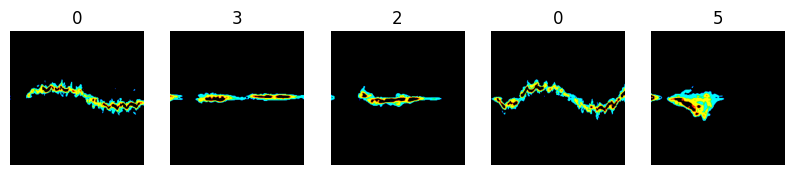

In [6]:
print(len(train_dataset_mask))
print(len(test_dataset_mask))
print(len(dataset_mask))

def show_image(img, title=""):
    # Convert the tensor to a numpy array and transpose to (H, W, C)
    img = np.transpose(img.numpy(), (1, 2, 0))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

# Visualize a few images
plt.figure(figsize=(10, 5))
for i in range(5):
  img, img_name = train_dataset_mask[i]
  plt.subplot(1, 5, i + 1)
  show_image(img, title=img_name)
plt.show()

In [34]:
# define the cnn model
class convnet(nn.Module):
    def __init__(self, num_classes=1000):
        super(convnet, self).__init__()
        self.features = nn.Sequential(
            # module 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # module 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # module 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(128, num_classes),
            nn.Dropout(),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [38]:
# cnn with se block
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction_ratio=8):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction_ratio, in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ConvSE(nn.Module):
    def __init__(self, num_classes=1000):
        super(ConvSE, self).__init__()
        self.module1 = nn.Sequential(
            # module 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.module2 = nn.Sequential(
            # module 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.module3 = nn.Sequential(
            # module 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.se = SEBlock(in_channels=224)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.classifier = nn.Sequential(
            nn.Linear(224 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(128, num_classes),
            nn.Dropout(),
        )

    def forward(self, x):
        x = self.module1(x)
        x1 = self.maxpool(self.maxpool(self.maxpool(x)))
        x = self.module2(x)
        x2 = self.maxpool(x)
        x = self.module3(x)

        x = torch.cat((x1,x2,x),dim=1)
        x = self.se(x)

        x = x.view(x.size(0), -1)
        x = self.classifier(x)

        return x

In [49]:
%pip install torch.onnx
import torch.onnx

# Define the dummy input for the model
dummy_input = torch.randn(1, 3, 224, 224)

# Export the model to ONNX
torch.onnx.export(model, dummy_input, "model.onnx")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.9/624.9 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 41.5 MB/s eta 0:00:00


In [29]:
# define the loss function
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = torch.nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return torch.mean(F_loss)

In [30]:
# define the model training and validation function
def train_model(model, train_loader, criterion, optimizer, device, epochs):
    model.train()
    train_loss, total_samples, total_correct = 0,0,0

    for i,(img, labels) in enumerate(tqdm(train_loader)):
        img, labels = img.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(img)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data,1)

        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
        accuracy = (total_correct/total_samples)*100

    print("Training Epoch: [{}]  loss: [{:.2f}] Accuracy :[{:.2f} %]".format(epochs+1, train_loss/len(train_loader), accuracy))

    return train_loss/len(train_loader), accuracy

def validate_model(model, test_loader, criterion,  device, epochs):
    model.eval()
    test_loss, total_samples, total_correct = 0,0,0
    with torch.no_grad():
        for i,(imgs, labels) in enumerate(tqdm(test_loader)):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data,1)

            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)
            accuracy = (total_correct/total_samples)*100

    print("Validation Epoch: [{}]  loss: [{:.2f}] Accuracy :[{:.2f} %]".format(epochs+1, test_loss/len(test_loader), accuracy))

    return test_loss/len(test_loader), accuracy

In [31]:
# define the model evaluation function
from sklearn.metrics import accuracy_score,f1_score, precision_score, roc_auc_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

def Classifier(y_test, y_pred):

    # print the scores
    print("Accuracy: " + str(accuracy_score(y_test,y_pred)))
    print("Precison score: " + str(precision_score(y_test,y_pred, average='macro')))
    print("Recall score: " + str(recall_score(y_test,y_pred, average='macro')))
    print("F1 score: " + str(f1_score(y_test,y_pred, average='macro')))

    # plot the confusion matrix

    plt.figure(figsize=(5,5))
    cm = confusion_matrix(y_test,y_pred,labels=[0,1,2,3,4,5])
    #plt.imshow(cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[1,2,3,4,5,6])
    disp.plot()
    plt.title("Confusion Matrix")
    plt.show()

In [11]:
# perform 4-fold cross-validation for hyperparameter tuning
k=4
splits=KFold(n_splits=k,shuffle=True,random_state=42)
per_fold_result={}
num_epochs = 30

for i, (train_idx,val_idx) in enumerate(splits.split(np.arange(len(train_dataset_td)))):

    print("Fold no.{}:".format(i + 1))

    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(val_idx)
    train_loader = DataLoader(train_dataset_td, batch_size=32, sampler=train_sampler)
    valid_loader = DataLoader(train_dataset_td, batch_size=32, sampler=valid_sampler)

    # Define the model
    model = convnet(num_classes=6)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(device)
    model = model.to(device)

    # Define loss function and optimizer
    # criterion = nn.CrossEntropyLoss()
    criterion = FocalLoss(alpha=1,gamma=2)
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    #optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9, weight_decay=0.0005)
    # scheduler = LinearWarmupExponentialDecayScheduler(optimizer, warmup_steps=1000, max_lr=0.005, decay_steps=5000)


    history = {'train_loss': [], 'valid_loss': [],'train_acc':[],'valid_acc':[]}

    for epoch in range(num_epochs):
        train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device, epoch)
        valid_loss, valid_acc = validate_model(model, valid_loader, criterion, device, epoch)

        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)
        history['train_acc'].append(train_acc)
        history['valid_acc'].append(valid_acc)

    per_fold_result['fold{}'.format(i+1)] = history

Fold no.1:
cuda:0


100%|██████████| 31/31 [06:20<00:00, 12.27s/it]


Training Epoch: [1]  loss: [1.55] Accuracy :[30.71 %]


100%|██████████| 11/11 [02:05<00:00, 11.38s/it]


Validation Epoch: [1]  loss: [0.76] Accuracy :[68.40 %]


...

Validation Epoch: [29]  loss: [0.18] Accuracy :[91.08 %]


100%|██████████| 31/31 [00:12<00:00,  2.54it/s]


Training Epoch: [30]  loss: [0.46] Accuracy :[60.94 %]


100%|██████████| 11/11 [00:04<00:00,  2.56it/s]

Validation Epoch: [30]  loss: [0.16] Accuracy :[90.46 %]


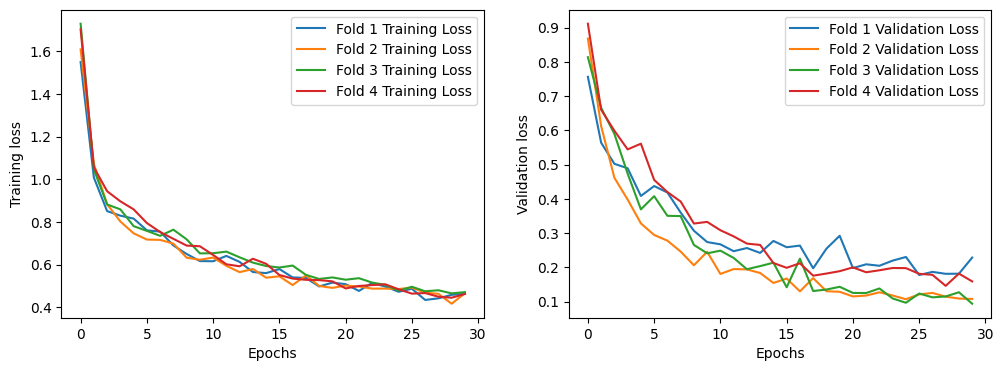

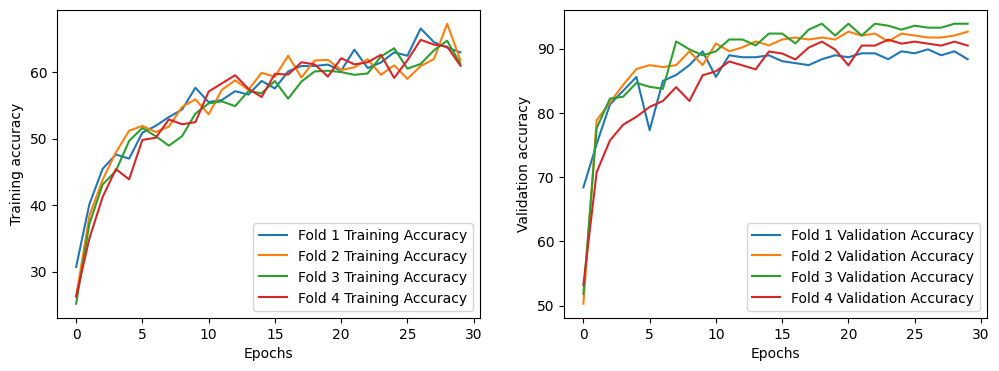

In [27]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(per_fold_result['fold1']['train_loss'],label='Fold 1 Training Loss')
plt.plot(per_fold_result['fold2']['train_loss'],label='Fold 2 Training Loss')
plt.plot(per_fold_result['fold3']['train_loss'],label='Fold 3 Training Loss')
plt.plot(per_fold_result['fold4']['train_loss'],label='Fold 4 Training Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Training loss')
plt.subplot(122)
plt.plot(per_fold_result['fold1']['valid_loss'],label='Fold 1 Validation Loss')
plt.plot(per_fold_result['fold2']['valid_loss'],label='Fold 2 Validation Loss')
plt.plot(per_fold_result['fold3']['valid_loss'],label='Fold 3 Validation Loss')
plt.plot(per_fold_result['fold4']['valid_loss'],label='Fold 4 Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(per_fold_result['fold1']['train_acc'],label='Fold 1 Training Accuracy')
plt.plot(per_fold_result['fold2']['train_acc'],label='Fold 2 Training Accuracy')
plt.plot(per_fold_result['fold3']['train_acc'],label='Fold 3 Training Accuracy')
plt.plot(per_fold_result['fold4']['train_acc'],label='Fold 4 Training Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Training accuracy')
plt.subplot(122)
plt.plot(per_fold_result['fold1']['valid_acc'],label='Fold 1 Validation Accuracy')
plt.plot(per_fold_result['fold2']['valid_acc'],label='Fold 2 Validation Accuracy')
plt.plot(per_fold_result['fold3']['valid_acc'],label='Fold 3 Validation Accuracy')
plt.plot(per_fold_result['fold4']['valid_acc'],label='Fold 4 Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')
plt.show()

cuda:0


100%|██████████| 41/41 [00:16<00:00,  2.54it/s]


Training Epoch: [1]  loss: [1.13] Accuracy :[30.31 %]


100%|██████████| 41/41 [00:25<00:00,  1.63it/s]


Training Epoch: [2]  loss: [0.93] Accuracy :[41.06 %]


...

100%|██████████| 41/41 [00:15<00:00,  2.60it/s]


Training Epoch: [29]  loss: [0.37] Accuracy :[65.54 %]


100%|██████████| 41/41 [00:16<00:00,  2.56it/s]


Training Epoch: [30]  loss: [0.37] Accuracy :[65.46 %]
Test Accuracy: 88.03680981595092%
Accuracy: 0.8803680981595092
Precison score: 0.9064173480840148
Recall score: 0.8860153256704981
F1 score: 0.8802150551260107


<Figure size 500x500 with 0 Axes>

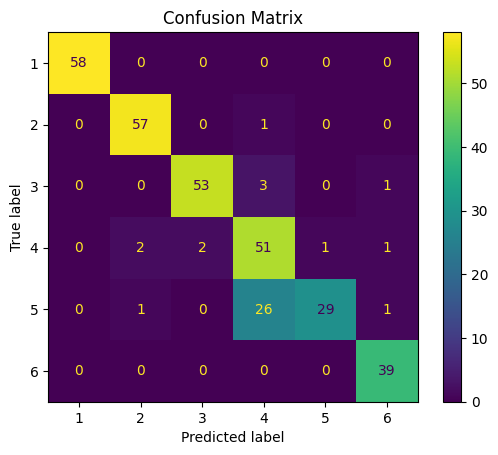

In [36]:
# model training and evaluation with spectrogram and cnn

# create dataloader
train_loader = DataLoader(train_dataset_td, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset_td, batch_size=len(test_dataset_td), shuffle=False)

# Define the model
model = convnet(num_classes=6)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

# Define loss function and optimizer
# criterion = nn.CrossEntropyLoss()
criterion = FocalLoss(alpha=1,gamma=2)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
#optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9, weight_decay=0.0005)
#scheduler = LinearWarmupExponentialDecayScheduler(optimizer, warmup_steps=1000, max_lr=0.005, decay_steps=5000)

# Train the model
num_epochs = 30
training_loss = []
for epoch in range(num_epochs):
  train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device, epoch)
  training_loss.append(train_loss)

# Evaluate the model
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for img, labels in test_loader:
        img, labels = img.to(device), labels.to(device)
        outputs = model(img)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy: {100 * correct / total}%')

Classifier(all_labels,all_preds)

In [39]:
# Path to save the model
save_path = '/content/drive/MyDrive/ff/model/Spec_cnn.pth'

# Save the trained model
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /content/drive/MyDrive/ff/model/Spec_cnn.pth


cuda:0


100%|██████████| 41/41 [00:16<00:00,  2.55it/s]


Training Epoch: [1]  loss: [1.14] Accuracy :[28.63 %]


100%|██████████| 41/41 [00:16<00:00,  2.52it/s]


Training Epoch: [2]  loss: [0.95] Accuracy :[39.91 %]


...

100%|██████████| 41/41 [00:15<00:00,  2.62it/s]


Training Epoch: [29]  loss: [0.36] Accuracy :[66.46 %]


100%|██████████| 41/41 [00:15<00:00,  2.64it/s]


Training Epoch: [30]  loss: [0.39] Accuracy :[63.24 %]
Test Accuracy: 93.55828220858896%
Accuracy: 0.9355828220858896
Precison score: 0.9394559846947415
Recall score: 0.9385964912280701
F1 score: 0.9376989152377612


<Figure size 500x500 with 0 Axes>

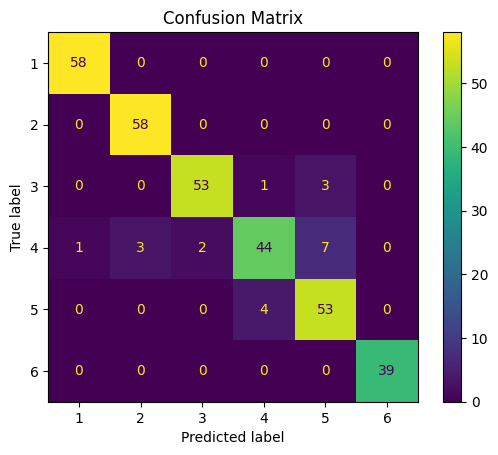

In [40]:
# model training and evaluation with spectrogram and cnn_se

# create dataloader
train_loader = DataLoader(train_dataset_td, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset_td, batch_size=len(test_dataset_td), shuffle=False)

# Define the model
model = ConvSE(num_classes=6)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

# Define loss function and optimizer
# criterion = nn.CrossEntropyLoss()
criterion = FocalLoss(alpha=1,gamma=2)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
#optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9, weight_decay=0.0005)
#scheduler = LinearWarmupExponentialDecayScheduler(optimizer, warmup_steps=1000, max_lr=0.005, decay_steps=5000)

# Train the model
num_epochs = 30
training_loss = []
for epoch in range(num_epochs):
  train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device, epoch)
  training_loss.append(train_loss)

# Evaluate the model
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for img, labels in test_loader:
        img, labels = img.to(device), labels.to(device)
        outputs = model(img)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy: {100 * correct / total}%')

Classifier(all_labels,all_preds)

In [41]:
# Path to save the model
save_path = '/content/drive/MyDrive/ff/model/spec_ConvSE.pth'

# Save the trained model
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /content/drive/MyDrive/ff/model/spec_ConvSE.pth


cuda:0


100%|██████████| 41/41 [09:11<00:00, 13.44s/it]


Training Epoch: [1]  loss: [1.19] Accuracy :[25.10 %]


100%|██████████| 41/41 [00:22<00:00,  1.79it/s]


Training Epoch: [2]  loss: [0.99] Accuracy :[38.30 %]


...

100%|██████████| 41/41 [00:22<00:00,  1.79it/s]


Training Epoch: [29]  loss: [0.37] Accuracy :[64.70 %]


100%|██████████| 41/41 [00:22<00:00,  1.78it/s]


Training Epoch: [30]  loss: [0.37] Accuracy :[67.61 %]
Test Accuracy: 90.79754601226993%
Accuracy: 0.9079754601226994
Precison score: 0.9110381463470544
Recall score: 0.912280701754386
F1 score: 0.9108410877355736


<Figure size 500x500 with 0 Axes>

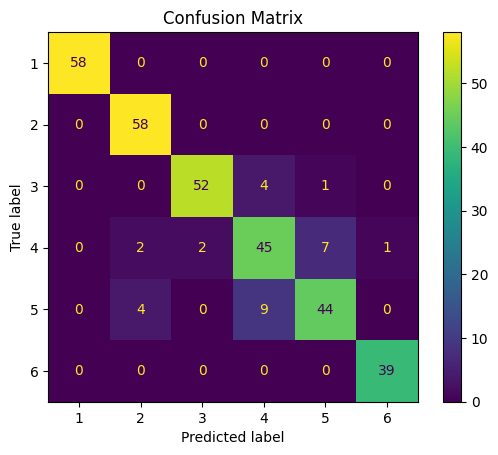

In [42]:
# model training and evaluation with masked_spectrogram and cnn

# create dataloader
train_loader = DataLoader(train_dataset_mask, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset_mask, batch_size=len(test_dataset_mask), shuffle=False)

# Define the model
model = convnet(num_classes=6)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

# Define loss function and optimizer
# criterion = nn.CrossEntropyLoss()
criterion = FocalLoss(alpha=1,gamma=2)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
#optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9, weight_decay=0.0005)
#scheduler = LinearWarmupExponentialDecayScheduler(optimizer, warmup_steps=1000, max_lr=0.005, decay_steps=5000)

# Train the model
num_epochs = 30
training_loss = []
for epoch in range(num_epochs):
  train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device, epoch)
  training_loss.append(train_loss)

# Evaluate the model
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for img, labels in test_loader:
        img, labels = img.to(device), labels.to(device)
        outputs = model(img)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy: {100 * correct / total}%')

Classifier(all_labels,all_preds)

In [43]:
# Path to save the model
save_path = '/content/drive/MyDrive/ff/model/Maskedspec_cnn.pth'

# Save the trained model
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /content/drive/MyDrive/ff/model/Maskedspec_cnn.pth


cuda:0


100%|██████████| 41/41 [00:21<00:00,  1.87it/s]


Training Epoch: [1]  loss: [1.17] Accuracy :[25.86 %]


100%|██████████| 41/41 [00:23<00:00,  1.78it/s]


Training Epoch: [2]  loss: [0.96] Accuracy :[40.60 %]


...

100%|██████████| 41/41 [00:22<00:00,  1.84it/s]


Training Epoch: [29]  loss: [0.38] Accuracy :[65.31 %]


100%|██████████| 41/41 [00:22<00:00,  1.81it/s]


Training Epoch: [30]  loss: [0.36] Accuracy :[66.46 %]
Test Accuracy: 92.02453987730061%
Accuracy: 0.9202453987730062
Precison score: 0.9277999445955171
Recall score: 0.9239766081871345
F1 score: 0.9217796609828551


<Figure size 500x500 with 0 Axes>

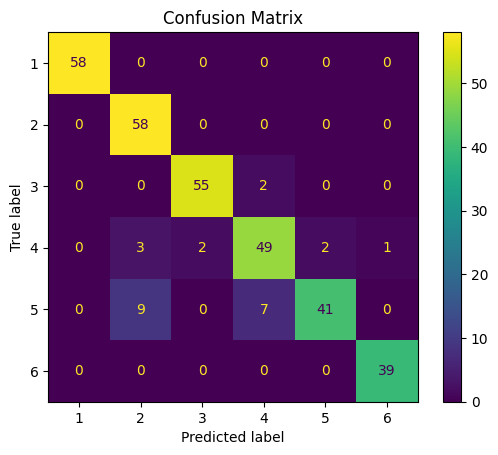

In [44]:
# model training and evaluation with masked_spectrogram and cnn

# create dataloader
train_loader = DataLoader(train_dataset_mask, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset_mask, batch_size=len(test_dataset_mask), shuffle=False)

# Define the model
model = ConvSE(num_classes=6)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

# Define loss function and optimizer
# criterion = nn.CrossEntropyLoss()
criterion = FocalLoss(alpha=1,gamma=2)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
#optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9, weight_decay=0.0005)
#scheduler = LinearWarmupExponentialDecayScheduler(optimizer, warmup_steps=1000, max_lr=0.005, decay_steps=5000)

# Train the model
num_epochs = 30
training_loss = []
for epoch in range(num_epochs):
  train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device, epoch)
  training_loss.append(train_loss)

# Evaluate the model
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for img, labels in test_loader:
        img, labels = img.to(device), labels.to(device)
        outputs = model(img)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy: {100 * correct / total}%')

Classifier(all_labels,all_preds)

In [45]:
# Path to save the model
save_path = '/content/drive/MyDrive/ff/model/Maskedspec_ConvSE.pth'

# Save the trained model
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /content/drive/MyDrive/ff/model/Maskedspec_ConvSE.pth
